In [1]:
# Cell 1: Install required libraries
%pip install -q pandas numpy matplotlib seaborn scikit-learn tensorflow joblib openpyxl

In [2]:
# Cell 2: Imports and setup

import os
import json
import random
import shutil
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

ARTIFACT_DIR = "/content/yield_risk_outputs"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("Artifacts will be saved in:", ARTIFACT_DIR)

TensorFlow version: 2.20.0
Artifacts will be saved in: /content/yield_risk_outputs


In [3]:
# Cell 3: Load dataset
# Keep yield_df.csv in Colab /content folder, or upload it when asked.

DATA_PATH = "/content/yield_df.csv"

if not os.path.exists(DATA_PATH):
    try:
        from google.colab import files
        print("Please upload yield_df.csv")
        uploaded = files.upload()
        DATA_PATH = list(uploaded.keys())[0]
    except Exception:
        DATA_PATH = "yield_df.csv"

df = pd.read_csv(DATA_PATH)
print("Dataset loaded:", df.shape)
display(df.head())

Please upload yield_df.csv


Saving yield_df.csv to yield_df.csv
Dataset loaded: (28242, 8)


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [4]:
# Cell 4: Basic cleaning

# Clean column names
clean_cols = []
for col in df.columns:
    clean_col = (
        col.strip()
        .lower()
        .replace("/", "_")
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
    )
    clean_cols.append(clean_col)

df.columns = clean_cols

# Remove index column if present
for col in ["unnamed:_0", "unnamed_0", "index"]:
    if col in df.columns:
        df = df.drop(columns=[col])

# Standard text format
if "area" in df.columns:
    df["area"] = df["area"].astype(str).str.strip()

if "item" in df.columns:
    df["item"] = df["item"].astype(str).str.strip()

# Remove duplicate rows
duplicates_before = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)

print("Cleaned shape:", df.shape)
print("Duplicates removed:", duplicates_before)
print(df.columns.tolist())
display(df.head())

Cleaned shape: (25932, 7)
Duplicates removed: 2310
['area', 'item', 'year', 'hg_ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']


,area,item,year,hg_ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

print("Shape:", df.shape)
print("Column types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_count"))

print("\nNumeric summary:")
display(df.describe())

print("\nTop crops:")
display(df["item"].value_counts().head(10).to_frame("count"))

Shape: (25932, 7)
Column types:
area                              object
item                              object
year                               int64
hg_ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object

Missing values:


,missing_count
area,0
item,0
year,0
hg_ha_yield,0
average_rain_fall_mm_per_year,0
pesticides_tonnes,0
avg_temp,0



Numeric summary:


,year,hg_ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,25932.000000,25932.000000,25932.000000,25932.000000,25932.000000
mean,2001.556455,76978.132925,1146.836688,34782.573241,20.422251
std,7.055924,84647.605552,717.391098,57228.568244,6.439402
min,1990.000000,50.000000,51.000000,0.040000,1.300000
25%,1995.000000,19996.000000,593.000000,1597.000000,16.580000
50%,2001.000000,39530.000000,1083.000000,15373.000000,21.420000
75%,2008.000000,104168.000000,1668.000000,45620.000000,26.060000
max,2013.000000,501412.000000,3240.000000,367778.000000,30.650000



Top crops:


,count
item,
Potatoes,3956
Maize,3824
Wheat,3539
"Rice, paddy",3091
Soybeans,2940
Sorghum,2770
Sweet potatoes,2593
Cassava,1889
Yams,774


In [9]:
# Cell 6: Handle missing values and cap outliers

# Fill missing numeric values with median
numeric_cols_raw = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols_raw:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values with mode
cat_cols_raw = df.select_dtypes(include=["object", "category"]).columns.tolist()
for col in cat_cols_raw:
    df[col] = df[col].fillna(df[col].mode()[0])

# Cap extreme outliers using IQR method
outlier_cols = [
    "average_rain_fall_mm_per_year",
    "pesticides_tonnes",
    "avg_temp",
    "hg_ha_yield"
]

for col in outlier_cols:
    if col in df.columns:
        q1 = df[col].quantile(0.01)
        q99 = df[col].quantile(0.99)
        df[col] = df[col].clip(q1, q99)

print("Missing values after handling:")
display(df.isna().sum().to_frame("missing_count"))

Missing values after handling:


,missing_count
area,0
item,0
year,0
hg_ha_yield,0
average_rain_fall_mm_per_year,0
pesticides_tonnes,0
avg_temp,0


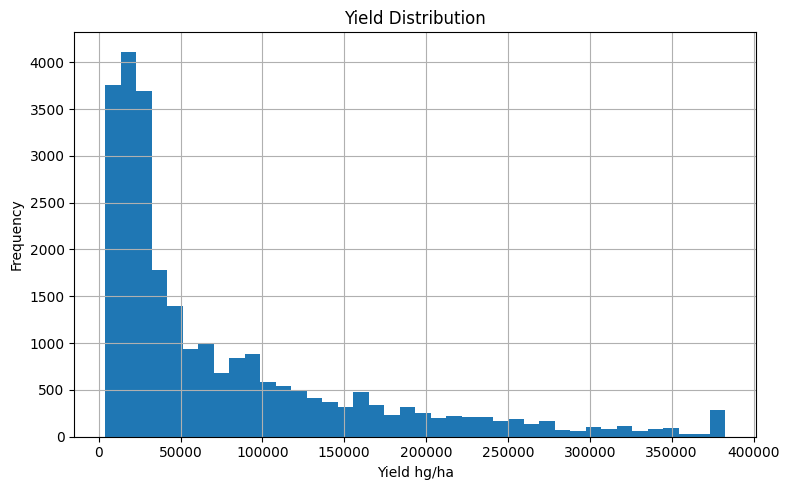

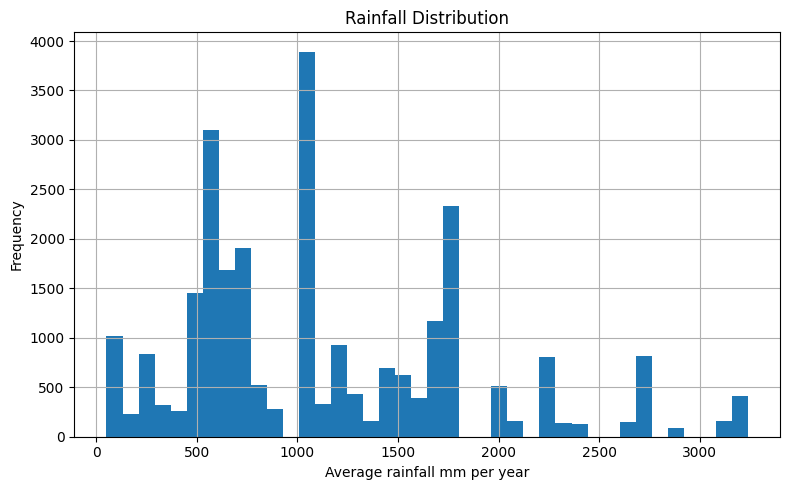

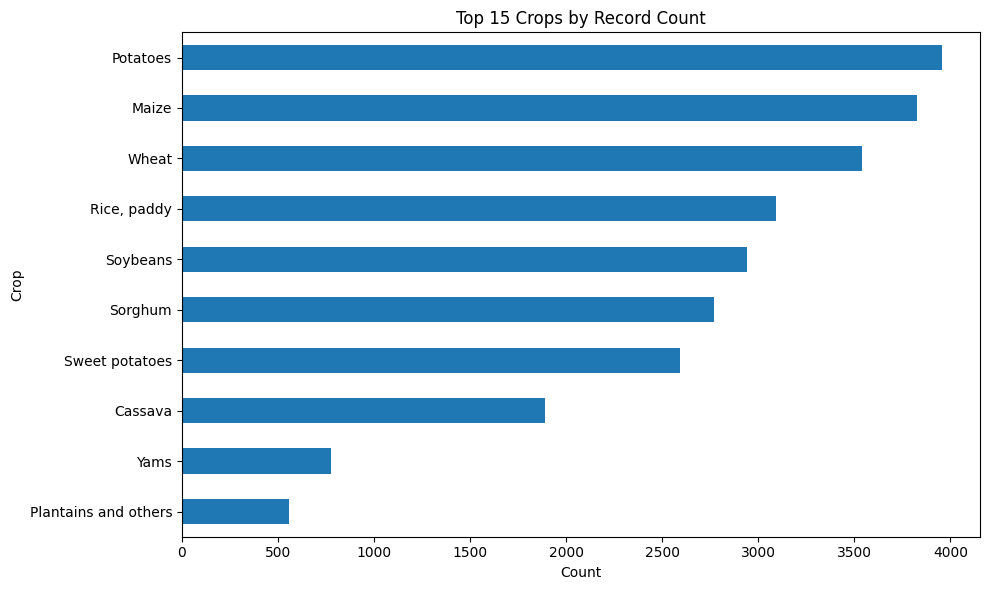

In [10]:
# Cell 7: EDA graphs

plt.figure(figsize=(8, 5))
df["hg_ha_yield"].hist(bins=40)
plt.title("Yield Distribution")
plt.xlabel("Yield hg/ha")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/eda_yield_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
df["average_rain_fall_mm_per_year"].hist(bins=40)
plt.title("Rainfall Distribution")
plt.xlabel("Average rainfall mm per year")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/eda_rainfall_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6))
df["item"].value_counts().head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Crops by Record Count")
plt.xlabel("Count")
plt.ylabel("Crop")
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/eda_top_crops.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# Cell 8: Create stronger yield_risk label
# The dataset does not have LOW, MEDIUM, HIGH risk directly.
# We create it using historical yield behavior plus weather volatility.
# Important: target-related columns are NOT used later as model inputs.


# Work on a clean copy
df_model = df.copy()
eps = 1e-6
yield_col = "hg_ha_yield"

# Expected yield per crop
# This gives the normal yield level for each crop.
df_model["expected_yield"] = df_model.groupby("item")[yield_col].transform("median")

# Yield ratio shows whether the actual yield is below or above normal crop yield.
df_model["yield_ratio"] = df_model[yield_col] / (df_model["expected_yield"] + eps)

# Crop-wise yield percentile
df_model["yield_percentile"] = df_model.groupby("item")["yield_ratio"].rank(pct=True)

# Low yield means higher risk.
df_model["yield_risk_score"] = np.where(
    df_model["yield_percentile"] <= 0.33,
    2,
    np.where(df_model["yield_percentile"] <= 0.66, 1, 0)
)

# Crop typical weather values
df_model["crop_median_rainfall"] = df_model.groupby("item")["average_rain_fall_mm_per_year"].transform("median")
df_model["crop_median_temp"] = df_model.groupby("item")["avg_temp"].transform("median")
df_model["crop_median_pesticides"] = df_model.groupby("item")["pesticides_tonnes"].transform("median")

# Weather volatility features
df_model["rainfall_volatility"] = (
    (df_model["average_rain_fall_mm_per_year"] - df_model["crop_median_rainfall"]).abs()
    / (df_model["crop_median_rainfall"].abs() + eps)
)

df_model["temp_volatility"] = (
    (df_model["avg_temp"] - df_model["crop_median_temp"]).abs()
    / (df_model["crop_median_temp"].abs() + eps)
)

df_model["pesticide_volatility"] = (
    (df_model["pesticides_tonnes"] - df_model["crop_median_pesticides"]).abs()
    / (df_model["crop_median_pesticides"].abs() + eps)
)

# Combined weather risk signal
df_model["weather_volatility_score"] = (
    df_model["rainfall_volatility"] * 0.45
    + df_model["temp_volatility"] * 0.45
    + df_model["pesticide_volatility"] * 0.10
)

# Convert weather volatility into 0, 1, 2 risk score
df_model["weather_risk_score"] = pd.qcut(
    df_model["weather_volatility_score"].rank(method="first"),
    q=3,
    labels=[0, 1, 2]
).astype(int)

# Final risk score combines yield history and weather volatility.
df_model["final_risk_score"] = (
    df_model["yield_risk_score"] * 0.60
    + df_model["weather_risk_score"] * 0.40
)

# Final label
# LOW means lower poor-yield risk. HIGH means higher poor-yield risk.
df_model["yield_risk"] = pd.qcut(
    df_model["final_risk_score"].rank(method="first"),
    q=3,
    labels=["LOW", "MEDIUM", "HIGH"]
)

print("Yield risk distribution:")
display(df_model["yield_risk"].value_counts().to_frame("count"))

Yield risk distribution:


,count
yield_risk,
LOW,8644
MEDIUM,8644
HIGH,8644


In [12]:
# Cell 9: Extra feature engineering
# These features help the ANN learn stronger weather and crop patterns.

df_model["pesticides_log"] = np.log1p(df_model["pesticides_tonnes"])
df_model["year_index"] = df_model["year"] - df_model["year"].min()

df_model["rainfall_temp_interaction"] = (
    df_model["average_rain_fall_mm_per_year"] * df_model["avg_temp"]
)

df_model["rainfall_to_temp_ratio"] = (
    df_model["average_rain_fall_mm_per_year"] / (df_model["avg_temp"] + eps)
)

df_model["pesticide_to_rainfall_ratio"] = (
    df_model["pesticides_tonnes"] / (df_model["average_rain_fall_mm_per_year"] + eps)
)

# Crop-level volatility reference features
df_model["crop_rainfall_std"] = df_model.groupby("item")["average_rain_fall_mm_per_year"].transform("std").fillna(0)
df_model["crop_temp_std"] = df_model.groupby("item")["avg_temp"].transform("std").fillna(0)
df_model["crop_pesticide_std"] = df_model.groupby("item")["pesticides_tonnes"].transform("std").fillna(0)

# Area + crop typical weather reference
df_model["area_crop_rainfall_median"] = (
    df_model.groupby(["area", "item"])["average_rain_fall_mm_per_year"].transform("median")
)

df_model["area_crop_temp_median"] = (
    df_model.groupby(["area", "item"])["avg_temp"].transform("median")
)

# Remove infinite values if any
df_model = df_model.replace([np.inf, -np.inf], np.nan)
df_model = df_model.dropna().reset_index(drop=True)

print("Final model dataframe shape:", df_model.shape)
display(df_model.head())

Final model dataframe shape: (25932, 31)


,area,item,year,hg_ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,expected_yield,yield_ratio,yield_percentile,...,pesticides_log,year_index,rainfall_temp_interaction,rainfall_to_temp_ratio,pesticide_to_rainfall_ratio,crop_rainfall_std,crop_temp_std,crop_pesticide_std,area_crop_rainfall_median,area_crop_temp_median
0,Albania,Maize,1990,36613.0,1485.0,121.0,16.37,25557.0,1.432602,0.639121,...,4.804021,0,24309.45,90.714717,0.081481,726.508603,6.743160,50976.185272,1485.0,16.450
1,Albania,Potatoes,1990,66667.0,1485.0,121.0,16.37,180322.5,0.369710,0.054348,...,4.804021,0,24309.45,90.714717,0.081481,695.191303,7.111253,50232.794566,1485.0,16.450
2,Albania,"Rice, paddy",1990,23333.0,1485.0,121.0,16.37,36408.0,0.640876,0.152378,...,4.804021,0,24309.45,90.714717,0.081481,744.240896,5.797883,55192.122297,1485.0,16.055
3,Albania,Sorghum,1990,12500.0,1485.0,121.0,16.37,13548.0,0.922645,0.476173,...,4.804021,0,24309.45,90.714717,0.081481,666.323728,5.550049,57511.576388,1485.0,16.060
4,Albania,Soybeans,1990,7000.0,1485.0,121.0,16.37,16006.0,0.437336,0.064456,...,4.804021,0,24309.45,90.714717,0.081481,697.764937,6.601626,55530.858000,1485.0,16.450


,risk_class,count
0,LOW,8644
1,MEDIUM,8644
2,HIGH,8644


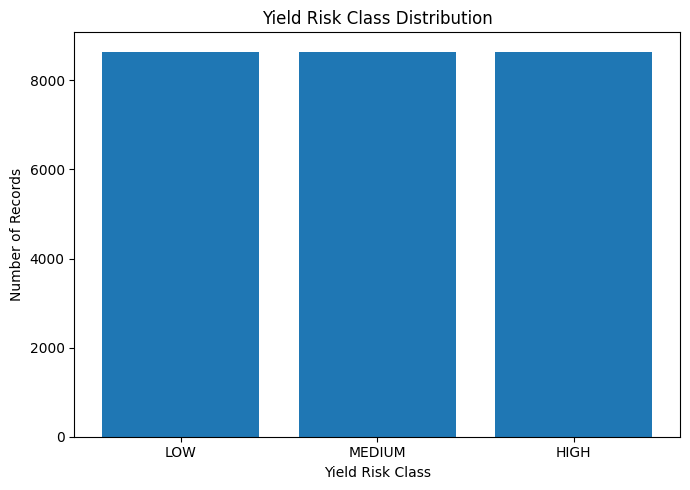

,count,mean,std,min,25%,50%,75%,max
rainfall_volatility,25932.0,0.566183,0.508777,0.000000,0.249115,0.416765,0.754902,3.274406
temp_volatility,25932.0,0.242507,0.179400,0.000000,0.094505,0.212646,0.347989,0.771559
pesticide_volatility,25932.0,2.122771,3.906198,0.000000,0.741346,0.982436,1.895249,62.860195
weather_volatility_score,25932.0,0.576188,0.458615,0.015796,0.324739,0.468639,0.653461,6.730154


In [13]:
# Cell 10: Save class balance and volatility summaries

class_balance_df = df_model["yield_risk"].value_counts().reindex(["LOW", "MEDIUM", "HIGH"]).reset_index()
class_balance_df.columns = ["risk_class", "count"]
display(class_balance_df)
class_balance_df.to_csv(f"{ARTIFACT_DIR}/class_balance_table.csv", index=False)

plt.figure(figsize=(7, 5))
plt.bar(class_balance_df["risk_class"], class_balance_df["count"])
plt.title("Yield Risk Class Distribution")
plt.xlabel("Yield Risk Class")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/class_balance_graph.png", dpi=300, bbox_inches="tight")
plt.show()

weather_volatility_cols = [
    "rainfall_volatility",
    "temp_volatility",
    "pesticide_volatility",
    "weather_volatility_score"
]

weather_volatility_summary = df_model[weather_volatility_cols].describe().T
display(weather_volatility_summary)
weather_volatility_summary.to_csv(f"{ARTIFACT_DIR}/weather_volatility_summary.csv")

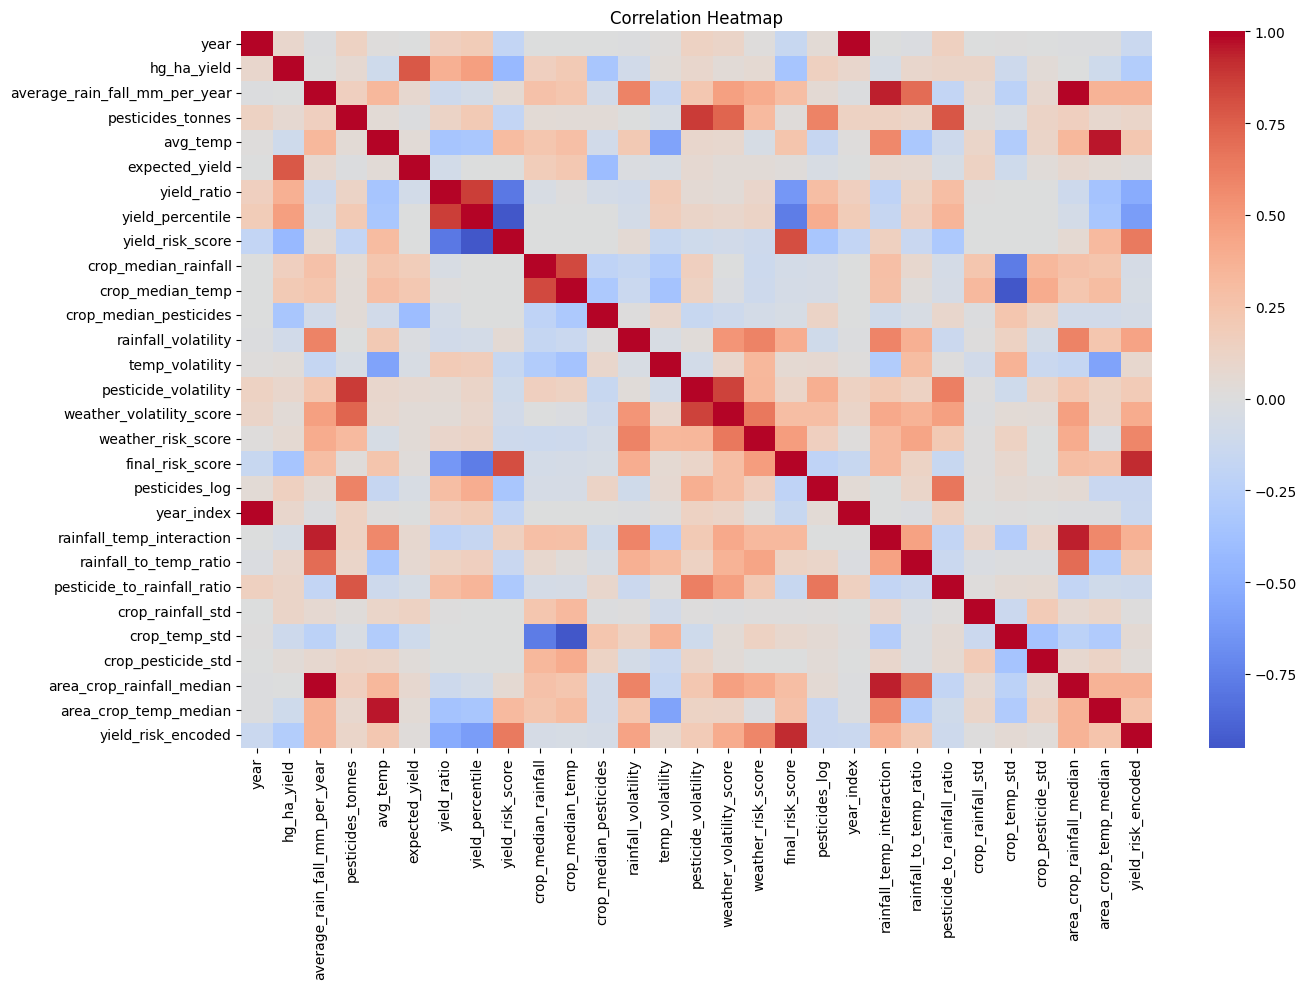

,feature,correlation_with_yield_risk
0,final_risk_score,0.916497
1,yield_risk_score,0.647851
2,weather_risk_score,0.586939
3,rainfall_volatility,0.448194
4,weather_volatility_score,0.403329
5,rainfall_temp_interaction,0.374106
6,area_crop_rainfall_median,0.362739
7,average_rain_fall_mm_per_year,0.362739
8,area_crop_temp_median,0.252347
9,avg_temp,0.225543


In [15]:
# Cell 11: Correlation analysis
# This is only for EDA and explanation.

risk_mapping = {"LOW": 0, "MEDIUM": 1, "HIGH": 2}
df_corr = df_model.copy()
df_corr["yield_risk_encoded"] = df_corr["yield_risk"].map(risk_mapping).astype(int)

corr_cols = df_corr.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

risk_corr = (
    correlation_matrix["yield_risk_encoded"]
    .drop("yield_risk_encoded")
    .sort_values(ascending=False)
    .reset_index()
)
risk_corr.columns = ["feature", "correlation_with_yield_risk"]
display(risk_corr.head(20))
risk_corr.to_csv(f"{ARTIFACT_DIR}/risk_correlation_table.csv", index=False)

In [17]:
# Cell 12: Final features and target
# Do not include yield or target-related columns as inputs. That would be data leakage.

target_col = "yield_risk"

leakage_cols = [
    "hg_ha_yield",
    "expected_yield",
    "yield_ratio",
    "yield_percentile",
    "yield_risk_score",
    "weather_risk_score",
    "final_risk_score",
    "yield_risk"
]

feature_cols = [col for col in df_model.columns if col not in leakage_cols]

X = df_model[feature_cols].copy()
y = df_model[target_col].copy()

print("Number of features before encoding:", len(feature_cols))
print(feature_cols)
print("\nTarget distribution:")
display(y.value_counts().to_frame("count"))

Number of features before encoding: 23
['area', 'item', 'year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'crop_median_rainfall', 'crop_median_temp', 'crop_median_pesticides', 'rainfall_volatility', 'temp_volatility', 'pesticide_volatility', 'weather_volatility_score', 'pesticides_log', 'year_index', 'rainfall_temp_interaction', 'rainfall_to_temp_ratio', 'pesticide_to_rainfall_ratio', 'crop_rainfall_std', 'crop_temp_std', 'crop_pesticide_std', 'area_crop_rainfall_median', 'area_crop_temp_median']

Target distribution:


,count
yield_risk,
LOW,8644
MEDIUM,8644
HIGH,8644


In [18]:
# Cell 13: Encode labels and split data

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
label_names = list(label_encoder.classes_)
id_to_label = {int(i): label for i, label in enumerate(label_names)}
label_to_id = {label: int(i) for i, label in enumerate(label_names)}
num_classes = len(label_names)

print("Label names:", label_names)
print("Label mapping:", label_to_id)

# 70% train, 15% validation, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.15,
    random_state=SEED,
    stratify=y_encoded
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.1765,
    random_state=SEED,
    stratify=y_temp
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Label names: ['HIGH', 'LOW', 'MEDIUM']
Label mapping: {'HIGH': 0, 'LOW': 1, 'MEDIUM': 2}
Train shape: (18151, 23)
Validation shape: (3891, 23)
Test shape: (3890, 23)


In [19]:
# Cell 14: Preprocessing
# Numeric columns are scaled. Text columns are one-hot encoded.

categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = [col for col in X_train.columns if col not in categorical_features]

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", one_hot, categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print("Processed train shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Categorical features: ['area', 'item']
Numeric features: ['year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'crop_median_rainfall', 'crop_median_temp', 'crop_median_pesticides', 'rainfall_volatility', 'temp_volatility', 'pesticide_volatility', 'weather_volatility_score', 'pesticides_log', 'year_index', 'rainfall_temp_interaction', 'rainfall_to_temp_ratio', 'pesticide_to_rainfall_ratio', 'crop_rainfall_std', 'crop_temp_std', 'crop_pesticide_std', 'area_crop_rainfall_median', 'area_crop_temp_median']
Processed train shape: (18151, 132)
Processed validation shape: (3891, 132)
Processed test shape: (3890, 132)


In [20]:
# Cell 15: Class weights
# This helps if one risk class has more records than others.

classes = np.unique(y_train)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = {int(cls): float(weight) for cls, weight in zip(classes, class_weights_array)}
print("Class weights:", class_weight_dict)

Class weights: {0: 0.9998898253732166, 1: 1.0000550964187327, 2: 1.0000550964187327}


Random Forest Validation Accuracy: 0.9352
Random Forest Macro F1: 0.9351
Random Forest Weighted F1: 0.9351

Random Forest Report:
              precision    recall  f1-score   support

        HIGH       0.94      0.96      0.95      1297
         LOW       0.94      0.95      0.95      1297
      MEDIUM       0.92      0.90      0.91      1297

    accuracy                           0.94      3891
   macro avg       0.94      0.94      0.94      3891
weighted avg       0.94      0.94      0.94      3891



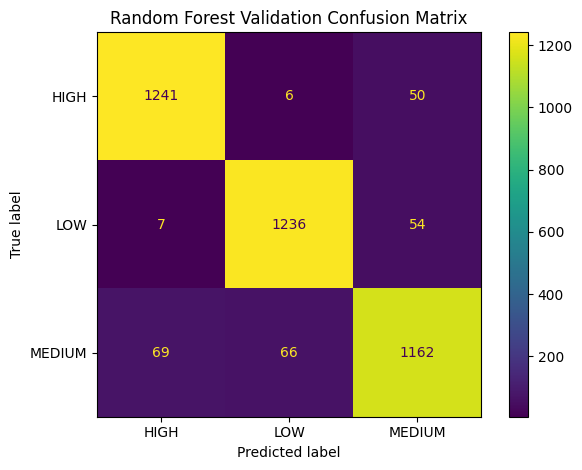

In [22]:
# Cell 16: Random Forest baseline
# This is only a comparison model. The required final model is ANN.

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=18,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)
rf_pred = rf_model.predict(X_val_processed)

rf_accuracy = accuracy_score(y_val, rf_pred)
rf_macro_f1 = f1_score(y_val, rf_pred, average="macro")
rf_weighted_f1 = f1_score(y_val, rf_pred, average="weighted")

print("Random Forest Validation Accuracy:", round(rf_accuracy, 4))
print("Random Forest Macro F1:", round(rf_macro_f1, 4))
print("Random Forest Weighted F1:", round(rf_weighted_f1, 4))
print("\nRandom Forest Report:")
print(classification_report(y_val, rf_pred, target_names=label_names))

rf_report_df = pd.DataFrame(
    classification_report(y_val, rf_pred, target_names=label_names, output_dict=True)
).transpose()
rf_report_df.to_csv(f"{ARTIFACT_DIR}/random_forest_validation_report.csv")

rf_cm = confusion_matrix(y_val, rf_pred)
ConfusionMatrixDisplay(rf_cm, display_labels=label_names).plot(values_format="d")
plt.title("Random Forest Validation Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/random_forest_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
# Cell 17: ANN tuning experiments
# This tests multiple honest ANN architectures to target 80%+ validation accuracy.
# No leakage columns are used.

experiments = [
    {
        "name": "ann_128_64_32_dropout_low_bs32",
        "layers": [128, 64, 32],
        "dropouts": [0.15, 0.10, 0.00],
        "batch_size": 32,
        "learning_rate": 0.001
    },
    {
        "name": "ann_256_128_64_dropout_low_bs32",
        "layers": [256, 128, 64],
        "dropouts": [0.20, 0.15, 0.05],
        "batch_size": 32,
        "learning_rate": 0.001
    },
    {
        "name": "ann_256_128_64_dropout_low_bs16",
        "layers": [256, 128, 64],
        "dropouts": [0.20, 0.15, 0.05],
        "batch_size": 16,
        "learning_rate": 0.001
    },
    {
        "name": "ann_512_256_128_dropout_medium_bs32",
        "layers": [512, 256, 128],
        "dropouts": [0.25, 0.20, 0.10],
        "batch_size": 32,
        "learning_rate": 0.0005
    },
    {
        "name": "ann_256_128_64_dropout_medium_bs64",
        "layers": [256, 128, 64],
        "dropouts": [0.20, 0.15, 0.05],
        "batch_size": 64,
        "learning_rate": 0.001
    }
]


def build_ann(input_dim, num_classes, layers, dropouts, learning_rate):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    for units, dropout_rate in zip(layers, dropouts):
        model.add(Dense(units, activation="relu"))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


results = []
best_model = None
best_history = None
best_val_accuracy = 0
best_model_name = None
best_exp = None

input_dim = X_train_processed.shape[1]
y_val_true = y_val

for exp in experiments:
    print("\nRunning experiment:", exp["name"])

    tf.keras.backend.clear_session()

    temp_model = build_ann(
        input_dim=input_dim,
        num_classes=num_classes,
        layers=exp["layers"],
        dropouts=exp["dropouts"],
        learning_rate=exp["learning_rate"]
    )

    early_stop = EarlyStopping(
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        mode="max",
        verbose=0
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=6,
        min_lr=0.00001,
        verbose=0
    )

    history = temp_model.fit(
        X_train_processed,
        y_train_cat,
        validation_data=(X_val_processed, y_val_cat),
        epochs=120,
        batch_size=exp["batch_size"],
        callbacks=[early_stop, reduce_lr],
        class_weight=class_weight_dict,
        verbose=0
    )

    y_val_prob = temp_model.predict(X_val_processed, verbose=0)
    y_val_pred = np.argmax(y_val_prob, axis=1)

    final_val_accuracy = accuracy_score(y_val_true, y_val_pred)
    final_macro_f1 = f1_score(y_val_true, y_val_pred, average="macro")
    best_history_val_accuracy = max(history.history["val_accuracy"])

    results.append({
        "model_name": exp["name"],
        "layers": str(exp["layers"]),
        "dropouts": str(exp["dropouts"]),
        "batch_size": exp["batch_size"],
        "learning_rate": exp["learning_rate"],
        "best_history_val_accuracy": best_history_val_accuracy,
        "final_val_accuracy": final_val_accuracy,
        "final_macro_f1": final_macro_f1,
        "epochs_ran": len(history.history["loss"])
    })

    print("Final validation accuracy:", round(final_val_accuracy, 4))
    print("Final macro F1:", round(final_macro_f1, 4))

    if final_val_accuracy > best_val_accuracy:
        best_val_accuracy = final_val_accuracy
        best_model = temp_model
        best_history = history
        best_model_name = exp["name"]
        best_exp = exp


results_df = pd.DataFrame(results).sort_values(by="final_val_accuracy", ascending=False)
display(results_df)

results_df.to_csv(f"{ARTIFACT_DIR}/ann_tuning_results.csv", index=False)

print("Best model:", best_model_name)
print("Best validation accuracy:", round(best_val_accuracy, 4))

model = best_model
history = best_history
model.save(f"{ARTIFACT_DIR}/best_ann_yield_risk_model.keras")
print("Best model saved.")


Running experiment: ann_128_64_32_dropout_low_bs32
Final validation accuracy: 0.9198
Final macro F1: 0.92

Running experiment: ann_256_128_64_dropout_low_bs32
Final validation accuracy: 0.9198
Final macro F1: 0.9198

Running experiment: ann_256_128_64_dropout_low_bs16
Final validation accuracy: 0.9219
Final macro F1: 0.9216

Running experiment: ann_512_256_128_dropout_medium_bs32
Final validation accuracy: 0.9198
Final macro F1: 0.9197

Running experiment: ann_256_128_64_dropout_medium_bs64
Final validation accuracy: 0.9226
Final macro F1: 0.9225


,model_name,layers,dropouts,batch_size,learning_rate,best_history_val_accuracy,final_val_accuracy,final_macro_f1,epochs_ran
4,ann_256_128_64_dropout_medium_bs64,"[256, 128, 64]","[0.2, 0.15, 0.05]",64,0.0010,0.922642,0.922642,0.922534,70
2,ann_256_128_64_dropout_low_bs16,"[256, 128, 64]","[0.2, 0.15, 0.05]",16,0.0010,0.921871,0.921871,0.921632,81
0,ann_128_64_32_dropout_low_bs32,"[128, 64, 32]","[0.15, 0.1, 0.0]",32,0.0010,0.919815,0.919815,0.919958,68
1,ann_256_128_64_dropout_low_bs32,"[256, 128, 64]","[0.2, 0.15, 0.05]",32,0.0010,0.919815,0.919815,0.919846,60
3,ann_512_256_128_dropout_medium_bs32,"[512, 256, 128]","[0.25, 0.2, 0.1]",32,0.0005,0.919815,0.919815,0.919673,70


Best model: ann_256_128_64_dropout_medium_bs64
Best validation accuracy: 0.9226
Best model saved.


,accuracy,loss,val_accuracy,val_loss,learning_rate
65,0.944135,0.129647,0.920586,0.226925,0.000063
66,0.940664,0.131391,0.920072,0.226296,0.000063
67,0.942758,0.131195,0.920843,0.225342,0.000031
68,0.944631,0.128538,0.920843,0.225417,0.000031
69,0.943089,0.129487,0.920072,0.225624,0.000031


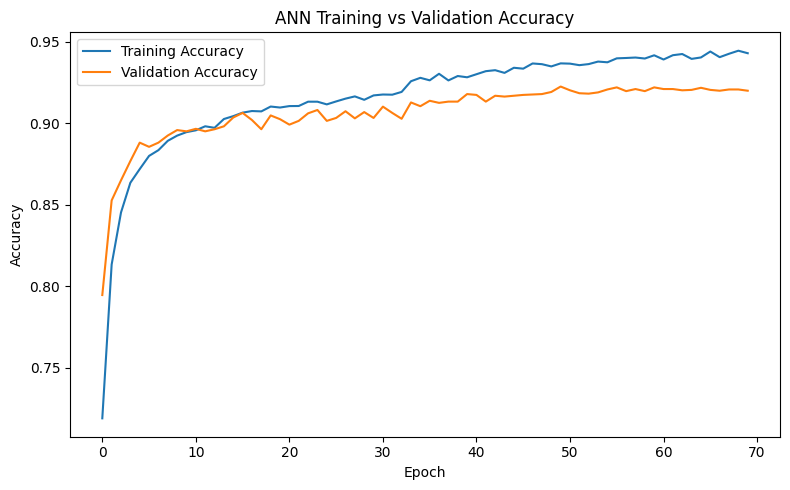

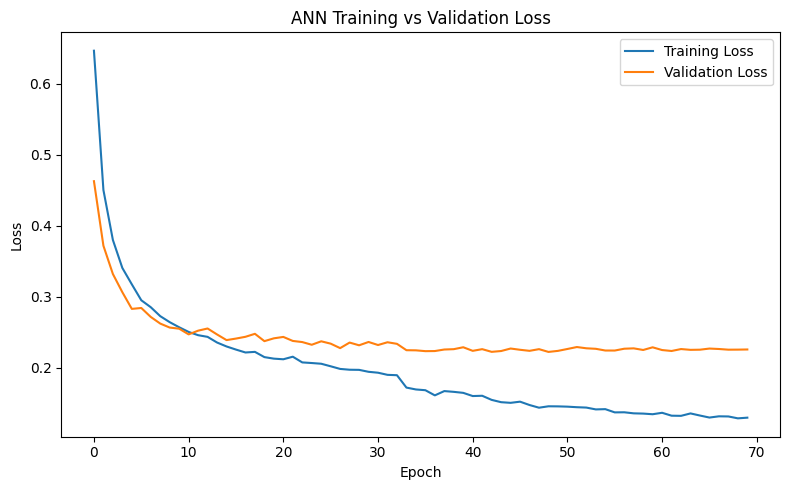

In [25]:
# Cell 18: Training graphs for best ANN

history_df = pd.DataFrame(history.history)
history_df.to_csv(f"{ARTIFACT_DIR}/ann_training_history.csv", index=False)
display(history_df.tail())

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("ANN Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/ann_accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("ANN Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/ann_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

Validation Accuracy: 0.9226
Validation Macro F1: 0.9225
Validation Weighted F1: 0.9225

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.94      0.95      0.94      1297
         LOW       0.94      0.94      0.94      1297
      MEDIUM       0.89      0.88      0.89      1297

    accuracy                           0.92      3891
   macro avg       0.92      0.92      0.92      3891
weighted avg       0.92      0.92      0.92      3891



,precision,recall,f1-score,support
HIGH,0.936073,0.948342,0.942168,1297.000000
LOW,0.939768,0.938319,0.939043,1297.000000
MEDIUM,0.891576,0.881264,0.886390,1297.000000
accuracy,0.922642,0.922642,0.922642,0.922642
macro avg,0.922472,0.922642,0.922534,3891.000000
weighted avg,0.922472,0.922642,0.922534,3891.000000


,risk_class,f1_score
0,HIGH,0.942168
1,LOW,0.939043
2,MEDIUM,0.886390


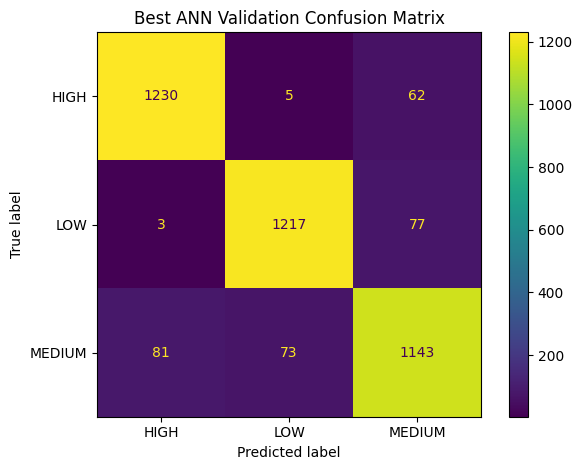

In [27]:
# Cell 19: Final validation evaluation for best ANN

y_val_prob = model.predict(X_val_processed, verbose=0)
y_val_pred = np.argmax(y_val_prob, axis=1)

val_accuracy = accuracy_score(y_val, y_val_pred)
val_macro_f1 = f1_score(y_val, y_val_pred, average="macro")
val_weighted_f1 = f1_score(y_val, y_val_pred, average="weighted")

print("Validation Accuracy:", round(val_accuracy, 4))
print("Validation Macro F1:", round(val_macro_f1, 4))
print("Validation Weighted F1:", round(val_weighted_f1, 4))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=label_names))

val_report_df = pd.DataFrame(
    classification_report(y_val, y_val_pred, target_names=label_names, output_dict=True)
).transpose()
display(val_report_df)
val_report_df.to_csv(f"{ARTIFACT_DIR}/best_ann_validation_report.csv")

val_f1_values = f1_score(y_val, y_val_pred, average=None, labels=list(range(num_classes)))
val_f1_table = pd.DataFrame({
    "risk_class": label_names,
    "f1_score": val_f1_values
})
display(val_f1_table)
val_f1_table.to_csv(f"{ARTIFACT_DIR}/ann_f1_score_per_class_validation.csv", index=False)

val_cm = confusion_matrix(y_val, y_val_pred)
ConfusionMatrixDisplay(val_cm, display_labels=label_names).plot(values_format="d")
plt.title("Best ANN Validation Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/best_ann_validation_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

Test Accuracy: 0.9185
Test Macro F1: 0.9183
Test Weighted F1: 0.9183

Test Classification Report:
              precision    recall  f1-score   support

        HIGH       0.94      0.96      0.95      1296
         LOW       0.93      0.93      0.93      1297
      MEDIUM       0.89      0.87      0.88      1297

    accuracy                           0.92      3890
   macro avg       0.92      0.92      0.92      3890
weighted avg       0.92      0.92      0.92      3890



,precision,recall,f1-score,support
HIGH,0.935094,0.956019,0.945441,1296.000000
LOW,0.931061,0.926754,0.928903,1297.000000
MEDIUM,0.888540,0.872783,0.880591,1297.000000
accuracy,0.918509,0.918509,0.918509,0.918509
macro avg,0.918232,0.918519,0.918312,3890.000000
weighted avg,0.918228,0.918509,0.918305,3890.000000


,risk_class,f1_score
0,HIGH,0.945441
1,LOW,0.928903
2,MEDIUM,0.880591


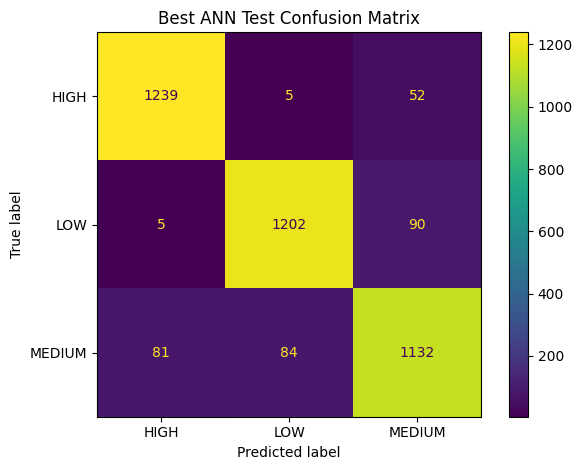

In [29]:
# Cell 20: Final test evaluation for best ANN
# Use this as final unbiased model result.

y_test_prob = model.predict(X_test_processed, verbose=0)
y_test_pred = np.argmax(y_test_prob, axis=1)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_macro_f1 = f1_score(y_test, y_test_pred, average="macro")
test_weighted_f1 = f1_score(y_test, y_test_pred, average="weighted")

print("Test Accuracy:", round(test_accuracy, 4))
print("Test Macro F1:", round(test_macro_f1, 4))
print("Test Weighted F1:", round(test_weighted_f1, 4))

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=label_names))

test_report_df = pd.DataFrame(
    classification_report(y_test, y_test_pred, target_names=label_names, output_dict=True)
).transpose()
display(test_report_df)
test_report_df.to_csv(f"{ARTIFACT_DIR}/best_ann_test_report.csv")

test_f1_values = f1_score(y_test, y_test_pred, average=None, labels=list(range(num_classes)))
test_f1_table = pd.DataFrame({
    "risk_class": label_names,
    "f1_score": test_f1_values
})
display(test_f1_table)
test_f1_table.to_csv(f"{ARTIFACT_DIR}/ann_f1_score_per_class_test.csv", index=False)

test_cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(test_cm, display_labels=label_names).plot(values_format="d")
plt.title("Best ANN Test Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/best_ann_test_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
# Cell 21: Model comparison table

model_comparison = pd.DataFrame({
    "model": ["Random Forest Baseline", "Best ANN"],
    "validation_accuracy": [rf_accuracy, val_accuracy],
    "validation_macro_f1": [rf_macro_f1, val_macro_f1],
    "purpose": ["comparison only", "final required neural network model"]
})

display(model_comparison)
model_comparison.to_csv(f"{ARTIFACT_DIR}/model_comparison.csv", index=False)

,model,validation_accuracy,validation_macro_f1,purpose
0,Random Forest Baseline,0.935235,0.935066,comparison only
1,Best ANN,0.922642,0.922534,final required neural network model


In [31]:
# Cell 22: Save model objects and reference stats

# Reference stats for prediction on new data
crop_reference_stats = df_model.groupby("item").agg(
    crop_median_rainfall=("average_rain_fall_mm_per_year", "median"),
    crop_median_temp=("avg_temp", "median"),
    crop_median_pesticides=("pesticides_tonnes", "median"),
    crop_rainfall_std=("average_rain_fall_mm_per_year", "std"),
    crop_temp_std=("avg_temp", "std"),
    crop_pesticide_std=("pesticides_tonnes", "std")
).reset_index().fillna(0)

area_crop_reference_stats = df_model.groupby(["area", "item"]).agg(
    area_crop_rainfall_median=("average_rain_fall_mm_per_year", "median"),
    area_crop_temp_median=("avg_temp", "median")
).reset_index()

crop_reference_stats.to_csv(f"{ARTIFACT_DIR}/crop_reference_stats.csv", index=False)
area_crop_reference_stats.to_csv(f"{ARTIFACT_DIR}/area_crop_reference_stats.csv", index=False)

joblib.dump(preprocessor, f"{ARTIFACT_DIR}/yield_risk_preprocessor.joblib")
joblib.dump(label_encoder, f"{ARTIFACT_DIR}/yield_risk_label_encoder.joblib")
model.save(f"{ARTIFACT_DIR}/final_ann_yield_risk_model.keras")

with open(f"{ARTIFACT_DIR}/yield_risk_labels.json", "w") as f:
    json.dump({"id_to_label": id_to_label, "label_to_id": label_to_id}, f, indent=4)

with open(f"{ARTIFACT_DIR}/yield_risk_features.json", "w") as f:
    json.dump({"feature_cols": feature_cols}, f, indent=4)

summary = f"""
Yield Risk Classifier ANN Summary

Best model: {best_model_name}
Best experiment: {best_exp}
Validation accuracy: {val_accuracy:.4f}
Validation macro F1: {val_macro_f1:.4f}
Test accuracy: {test_accuracy:.4f}
Test macro F1: {test_macro_f1:.4f}

Activation functions:
ReLU was used in hidden layers.
Softmax was used in the output layer.

Training choices:
Optimizer: Adam
Loss: categorical_crossentropy
Class weights: Yes
Early stopping: Yes
Dropout: Yes
"""

with open(f"{ARTIFACT_DIR}/final_model_summary.txt", "w") as f:
    f.write(summary)

print(summary)
print("All model files saved in:", ARTIFACT_DIR)


Yield Risk Classifier ANN Summary

Best model: ann_256_128_64_dropout_medium_bs64
Best experiment: {'name': 'ann_256_128_64_dropout_medium_bs64', 'layers': [256, 128, 64], 'dropouts': [0.2, 0.15, 0.05], 'batch_size': 64, 'learning_rate': 0.001}
Validation accuracy: 0.9226
Validation macro F1: 0.9225
Test accuracy: 0.9185
Test macro F1: 0.9183

Activation functions:
ReLU was used in hidden layers.
Softmax was used in the output layer.

Training choices:
Optimizer: Adam
Loss: categorical_crossentropy
Class weights: Yes
Early stopping: Yes
Dropout: Yes

All model files saved in: /content/yield_risk_outputs


In [32]:
# Cell 23: Prediction function for final app integration
# Your partner's Model 1 will send recommended_crop to this function.


def _lookup_crop_stats(recommended_crop):
    crop_row = crop_reference_stats[crop_reference_stats["item"] == recommended_crop]

    if len(crop_row) == 0:
        # fallback to median of all crop stats
        return {
            "crop_median_rainfall": float(crop_reference_stats["crop_median_rainfall"].median()),
            "crop_median_temp": float(crop_reference_stats["crop_median_temp"].median()),
            "crop_median_pesticides": float(crop_reference_stats["crop_median_pesticides"].median()),
            "crop_rainfall_std": float(crop_reference_stats["crop_rainfall_std"].median()),
            "crop_temp_std": float(crop_reference_stats["crop_temp_std"].median()),
            "crop_pesticide_std": float(crop_reference_stats["crop_pesticide_std"].median())
        }

    row = crop_row.iloc[0]
    return {
        "crop_median_rainfall": float(row["crop_median_rainfall"]),
        "crop_median_temp": float(row["crop_median_temp"]),
        "crop_median_pesticides": float(row["crop_median_pesticides"]),
        "crop_rainfall_std": float(row["crop_rainfall_std"]),
        "crop_temp_std": float(row["crop_temp_std"]),
        "crop_pesticide_std": float(row["crop_pesticide_std"])
    }


def _lookup_area_crop_stats(area, recommended_crop, crop_stats):
    area_crop_row = area_crop_reference_stats[
        (area_crop_reference_stats["area"] == area)
        & (area_crop_reference_stats["item"] == recommended_crop)
    ]

    if len(area_crop_row) == 0:
        return {
            "area_crop_rainfall_median": crop_stats["crop_median_rainfall"],
            "area_crop_temp_median": crop_stats["crop_median_temp"]
        }

    row = area_crop_row.iloc[0]
    return {
        "area_crop_rainfall_median": float(row["area_crop_rainfall_median"]),
        "area_crop_temp_median": float(row["area_crop_temp_median"])
    }


def build_prediction_row(
    area,
    recommended_crop,
    year,
    average_rain_fall_mm_per_year,
    pesticides_tonnes,
    avg_temp
):
    area = str(area).strip()
    recommended_crop = str(recommended_crop).strip()

    crop_stats = _lookup_crop_stats(recommended_crop)
    area_crop_stats = _lookup_area_crop_stats(area, recommended_crop, crop_stats)

    row = pd.DataFrame([{
        "area": area,
        "item": recommended_crop,
        "year": int(year),
        "average_rain_fall_mm_per_year": float(average_rain_fall_mm_per_year),
        "pesticides_tonnes": float(pesticides_tonnes),
        "avg_temp": float(avg_temp),
        "crop_median_rainfall": crop_stats["crop_median_rainfall"],
        "crop_median_temp": crop_stats["crop_median_temp"],
        "crop_median_pesticides": crop_stats["crop_median_pesticides"],
        "crop_rainfall_std": crop_stats["crop_rainfall_std"],
        "crop_temp_std": crop_stats["crop_temp_std"],
        "crop_pesticide_std": crop_stats["crop_pesticide_std"],
        "area_crop_rainfall_median": area_crop_stats["area_crop_rainfall_median"],
        "area_crop_temp_median": area_crop_stats["area_crop_temp_median"]
    }])

    row["rainfall_volatility"] = (
        (row["average_rain_fall_mm_per_year"] - row["crop_median_rainfall"]).abs()
        / (row["crop_median_rainfall"].abs() + eps)
    )

    row["temp_volatility"] = (
        (row["avg_temp"] - row["crop_median_temp"]).abs()
        / (row["crop_median_temp"].abs() + eps)
    )

    row["pesticide_volatility"] = (
        (row["pesticides_tonnes"] - row["crop_median_pesticides"]).abs()
        / (row["crop_median_pesticides"].abs() + eps)
    )

    row["weather_volatility_score"] = (
        row["rainfall_volatility"] * 0.45
        + row["temp_volatility"] * 0.45
        + row["pesticide_volatility"] * 0.10
    )

    row["pesticides_log"] = np.log1p(row["pesticides_tonnes"])
    row["year_index"] = row["year"] - int(df_model["year"].min())
    row["rainfall_temp_interaction"] = row["average_rain_fall_mm_per_year"] * row["avg_temp"]
    row["rainfall_to_temp_ratio"] = row["average_rain_fall_mm_per_year"] / (row["avg_temp"] + eps)
    row["pesticide_to_rainfall_ratio"] = row["pesticides_tonnes"] / (row["average_rain_fall_mm_per_year"] + eps)

    # Make sure column order is exactly same as training features
    return row[feature_cols]


def predict_yield_risk(
    area,
    recommended_crop,
    year,
    average_rain_fall_mm_per_year,
    pesticides_tonnes,
    avg_temp
):
    row = build_prediction_row(
        area=area,
        recommended_crop=recommended_crop,
        year=year,
        average_rain_fall_mm_per_year=average_rain_fall_mm_per_year,
        pesticides_tonnes=pesticides_tonnes,
        avg_temp=avg_temp
    )

    row_processed = preprocessor.transform(row)
    probabilities = model.predict(row_processed, verbose=0)[0]
    predicted_id = int(np.argmax(probabilities))
    predicted_label = id_to_label[predicted_id]

    probability_table = pd.DataFrame({
        "risk_class": label_names,
        "probability": probabilities
    }).sort_values(by="probability", ascending=False).reset_index(drop=True)

    return predicted_label, probability_table

print("Prediction function is ready.")

Prediction function is ready.


In [33]:
# Cell 24: Test prediction function using a real test row

demo_row = X_test.iloc[0]

predicted_label, probability_table = predict_yield_risk(
    area=demo_row["area"],
    recommended_crop=demo_row["item"],
    year=demo_row["year"],
    average_rain_fall_mm_per_year=demo_row["average_rain_fall_mm_per_year"],
    pesticides_tonnes=demo_row["pesticides_tonnes"],
    avg_temp=demo_row["avg_temp"]
)

print("Input row used:")
display(demo_row)

print("Predicted Yield Risk:", predicted_label)
display(probability_table)

Input row used:


,11309
area,India
item,Sorghum
year,1999
average_rain_fall_mm_per_year,1083.0
pesticides_tonnes,46195.0
avg_temp,25.74
crop_median_rainfall,832.0
crop_median_temp,21.86
crop_median_pesticides,14485.33
rainfall_volatility,0.301683


Predicted Yield Risk: HIGH


,risk_class,probability
0,HIGH,0.966180
1,MEDIUM,0.033814
2,LOW,0.000006


In [34]:
# Cell 25: Model 1 to Model 2 sample connection
# Replace Maize with your partner's crop recommendation output.

recommended_crop_from_model_1 = "Maize"

predicted_label, probability_table = predict_yield_risk(
    area="Pakistan",
    recommended_crop=recommended_crop_from_model_1,
    year=2024,
    average_rain_fall_mm_per_year=550,
    pesticides_tonnes=1200,
    avg_temp=25.5
)

if predicted_label == "LOW":
    tier = "GO"
    message = "Low predicted yield risk. Farmer can proceed."
elif predicted_label == "MEDIUM":
    tier = "CAUTION"
    message = "Medium predicted yield risk. Farmer should consider irrigation or backup planning."
else:
    tier = "HOLD"
    message = "High predicted yield risk. Farmer should consider an alternative crop."

print("Recommended crop:", recommended_crop_from_model_1)
print("Yield risk:", predicted_label)
print("Recommendation tier:", tier)
print("Plain English message:", message)
display(probability_table)

Recommended crop: Maize
Yield risk: LOW
Recommendation tier: GO
Plain English message: Low predicted yield risk. Farmer can proceed.


,risk_class,probability
0,LOW,9.974323e-01
1,MEDIUM,2.566799e-03
2,HIGH,9.666493e-07


In [35]:
# Cell 26: Create ZIP file and download all outputs

zip_path = shutil.make_archive(
    base_name="/content/yield_risk_outputs",
    format="zip",
    root_dir=ARTIFACT_DIR
)

print("ZIP created at:", zip_path)

try:
    from google.colab import files
    files.download("/content/yield_risk_outputs.zip")
except Exception as e:
    print("Download manually from:", zip_path)
    print(e)

ZIP created at: /content/yield_risk_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
# Cell 27: Optional, save ZIP permanently to Google Drive
# Run only if you want to keep files after Colab closes.
from google.colab import drive
drive.mount("/content/drive")
shutil.copy("/content/yield_risk_outputs.zip", "/content/drive/MyDrive/yield_risk_outputs.zip")
print("Saved to Google Drive: /content/drive/MyDrive/yield_risk_outputs.zip")

Mounted at /content/drive
Saved to Google Drive: /content/drive/MyDrive/yield_risk_outputs.zip


In [38]:
# Save and download Member 3 files

import os
import json
import joblib
import shutil
import pandas as pd
from google.colab import files

MEMBER3_DIR = "/content/member3_yield_risk_files"
os.makedirs(MEMBER3_DIR, exist_ok=True)

# 1. Save ANN model
model.save(f"{MEMBER3_DIR}/yield_risk_ann.h5")

# 2. Save preprocessor as risk scaler
# In your notebook, preprocessor includes scaling + one-hot encoding
joblib.dump(preprocessor, f"{MEMBER3_DIR}/risk_scaler.pkl")

# 3. Save label encoder / label mapping
try:
    joblib.dump(label_encoder, f"{MEMBER3_DIR}/risk_encoder.pkl")
except:
    label_data = {
        "label_names": list(label_names),
        "id_to_label": id_to_label
    }
    joblib.dump(label_data, f"{MEMBER3_DIR}/risk_encoder.pkl")

# 4. Save model metrics
metrics_data = {
    "validation_accuracy": float(val_accuracy) if "val_accuracy" in globals() else None,
    "macro_f1": float(val_macro_f1) if "val_macro_f1" in globals() else None,
    "weighted_f1": float(val_weighted_f1) if "val_weighted_f1" in globals() else None
}

with open(f"{MEMBER3_DIR}/model_metrics.json", "w") as f:
    json.dump(metrics_data, f, indent=4)

# 5. Save F1 scores if f1 table exists
try:
    f1_table.to_csv(f"{MEMBER3_DIR}/f1_scores.csv", index=False)
except:
    print("f1_table not found. Run evaluation cell first.")

# 6. Save confusion matrix image if already created in outputs folder
try:
    shutil.copy(
        "/content/yield_risk_outputs/ann_confusion_matrix.png",
        f"{MEMBER3_DIR}/confusion_matrix.png"
    )
except:
    print("Confusion matrix image not found. Run confusion matrix cell first.")

# 7. Create ZIP
zip_path = shutil.make_archive(
    base_name="/content/member3_yield_risk_files",
    format="zip",
    root_dir=MEMBER3_DIR
)

print("ZIP created:", zip_path)

# 8. Download ZIP
files.download("/content/member3_yield_risk_files.zip")

f1_table not found. Run evaluation cell first.
Confusion matrix image not found. Run confusion matrix cell first.
ZIP created: /content/member3_yield_risk_files.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>